# Projeto 2: Classificação binária brest cancer com validação cruzada e dropout


## Etapa 1: Importação das bibliotecas

Avaliação do algoritmo é a função da validação cruzada

Bibliotecas e base de dados

importaremos a biblioteca skorch

infelizemente o pytorch ainda não tem o recurso de validação cruzada própria, por isso usamos o skorch

é uma biblioteca complementar


In [1]:
#!pip install skorch

ambiente anconda YouTube

no terminal do linux 

conda env list

conda activate YouTube

In [2]:
import pandas as pd
import numpy as np
import torch.nn as nn
import skorch
# para problemas binários, que tem ou não tem câncer
from skorch import NeuralNetBinaryClassifier
import torch
import seaborn as sns
import sklearn
from sklearn.model_selection import cross_val_score
# a validação cruzada combinará torch, skorch e sklearn.

In [3]:
print('torch:',torch.__version__, '  skorch:', skorch.__version__, '  sklearn',sklearn.__version__)

torch: 2.8.0+cu128   skorch: 1.2.0   sklearn 1.4.2


## Etapa 2: Base de dados

In [4]:
# random.seed para sempre gerarmos o mesmo resultado.
np.random.seed(123)
torch.manual_seed(123)

np.random.seed(123)

Define uma "semente" para o gerador de números aleatórios do NumPy. O NumPy é a biblioteca fundamental para os processos em machine learning que dependem de geração de números aleatórios (por exemplo, inicialização de pesos em redes neurais, divisão aleatória de dados, amostragem em algoritmos).

- Define uma semente (seed), a sequência de números aleatórios gerada por ele será sempre a mesma. Isso significa que, se executar o código com a mesma semente, obteremos os mesmos resultados aleatórios todas as vezes. Isso é crucial para:

a) Depuração: Facilitar a identificação de erros, pois o comportamento aleatório será o mesmo.

b) Comparação: Permitir que comparemos diferentes modelos ou hiperparâmetros de forma justa, garantindo que as diferenças nos resultados se devam às nossas mudanças e não a variações aleatórias.

c) Reprodutibilidade: Permitir que outras pessoas (ou no futuro) reproduzam exatamente os mesmos resultados.



torch.manual_seed(123)

Similar ao np.random.seed, esta linha define uma semente para o gerador de números aleatórios da biblioteca PyTorch. O PyTorch é uma biblioteca popular para deep learning.

- Redes neurais, em particular, dependem muito de inicialização aleatória (pesos, vieses) e, às vezes, de outros processos aleatórios durante o treinamento. Definir a semente do PyTorch garante que essas inicializações e processos aleatórios sejam idênticos em cada execução. Isso é igualmente vital para:

a) Reprodutibilidade: Assegurar que os treinamentos de modelos com a mesma arquitetura e dados produzam os mesmos resultados.

b) Comparação justa: Facilitar a comparação de diferentes abordagens ou hiperparâmetros em um ambiente controlado.

In [5]:
previsores = pd.read_csv('entradas_breast.csv')
classe = pd.read_csv('saidas_breast.csv')

In [6]:
previsores.tail(5)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
564,21.56,22.39,142.00,1479.0,111.00000,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.45,26.40,166.10,2027.0,141.00000,0.21130,0.4107,0.2216,206.0000,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,144.00000,0.09791,0.1752,0.05533,...,23.69,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,159.0000,0.05648,...,18.98,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,277.00000,0.35140,152.00000,0.2397,0.07016,...,25.74,39.42,184.60,1821.0,165.00000,0.86810,0.9387,265.0000,0.4087,124.00000
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,9456.00,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [7]:
classe.tail(5)

,0
564,0
565,0
566,0
567,0
568,1


In [8]:
#sns.countplot(classe['0']);

In [9]:
np.unique(classe, return_counts=True)

(array([0, 1]), array([212, 357]))

In [10]:
valores_unicos, contagens = np.unique(classe, return_counts=True)
df_count = pd.DataFrame({
    'classe': valores_unicos,
    'contagem': contagens #
})
df_count

,classe,contagem
0,0,212
1,1,357


In [11]:
classe.tail(5)

,0
564,0
565,0
566,0
567,0
568,1


In [12]:
df_classe= classe.rename(columns={'0':'Classes'})

/tmp/ipykernel_11688/1231753703.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Classes', data=df_classe,palette='viridis')


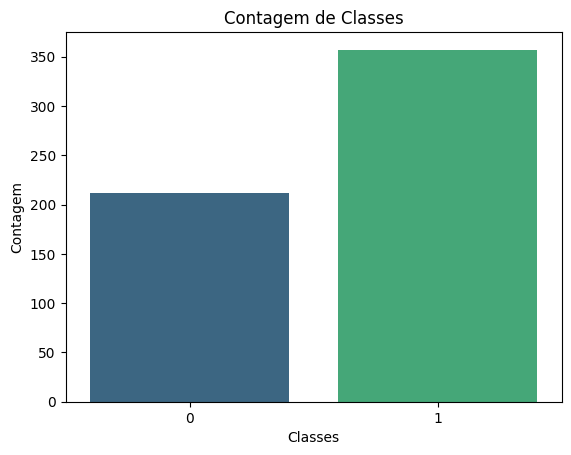

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plote a contagem usando a coluna 'Classes'
sns.countplot(x='Classes', data=df_classe,palette='viridis')


plt.title('Contagem de Classes')
plt.xlabel('Classes')
plt.ylabel('Contagem')

# Exiba o gráfico
plt.show();

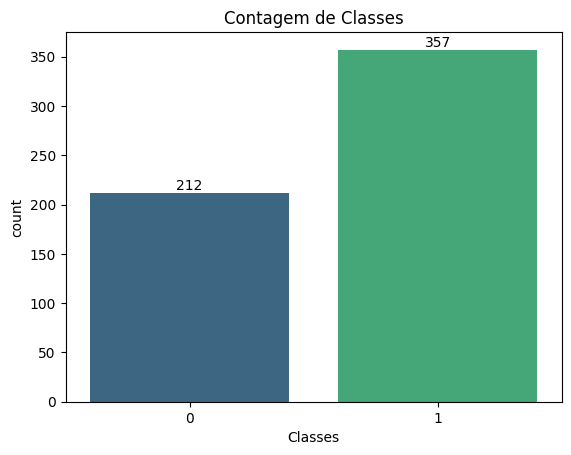

In [14]:

# Cria o gráfico e armazena o objeto de eixos (ax)
ax = sns.countplot(x='Classes', data=df_classe, palette='viridis', hue='Classes', legend=False)

# Adiciona um título para o gráfico
plt.title('Contagem de Classes')

# Itera sobre as barras (patches) e adiciona o valor de contagem
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', # Formato do texto
                (p.get_x() + p.get_width() / 2., p.get_height()), # Posição (x, y) do texto
                ha='center', # Alinhamento horizontal
                va='center', # Alinhamento vertical
                xytext=(0, 5), # Deslocamento do texto em relação à barra
                textcoords='offset points')

# Exibe o gráfico
plt.show()

In [15]:
classe.shape # quantidade de dados e colunas

(569, 1)

In [16]:
# transformar em array
previsores = np.array(previsores, dtype='float32')
classe = np.array(classe, dtype='float32').squeeze(1)

Converte para um array NumPy com tipo float32:

- np.array(classe, dtype='float32'): Pega os dados que estão em classe (no casoum dataframe Pandas) e os transforma em um array NumPy. O dtype='float32' especifica que todos os elementos do array devem ser números de ponto flutuante com precisão simples (32 bits). Isso é comum para otimizar o uso de memória e a velocidade de processamento, especialmente em GPUs.

Remove dimensões de tamanho 1:

- .squeeze(1): Este método remove todas as dimensões do array NumPy que têm tamanho 1. O (1) especifica que devemos remover apenas a dimensão no índice 1 (a segunda dimensão). Isso é útil quando tem um array que deveria ser unidimensional (como um vetor de rótulos ou classes), mas que acabou com uma dimensão extra de tamanho 1. (como mostra no shape)

In [17]:
classe.shape # quantidade de dados e retirado a dimensão para passar no pytorch

(569,)

In [18]:
print('tipo previsores =' , type(previsores) , '\ntipo classe =', type(classe))

tipo previsores = <class 'numpy.ndarray'> 
tipo classe = <class 'numpy.ndarray'>


- Classe para mudar a estrutura da rede neural 

- definir a rede neural em um formato de classe.

#### skorch é compativel com o pytorch e o sklearn

## Etapa 3: Classe para estrutura da rede neural

** ATUALIZAÇÃO DEZ/2021 **: na versão atual do Skorch, os resultados da rede neural devem ser retornados sem ativação, ou seja, sem a camada sigmoide no final. Com isto, a função de custo deve ser `BCEWithLogitsLoss`.

In [19]:
# classe do pytorch
class classificador_torch(nn.Module):
  # construção da classe
  def __init__(self):
    super().__init__() # super classe, herdando a classe module

    # definir as camadas
      
    # 30 -> 16 -> 16 -> 1
    # 1° camada densa (liga camada de entrada com 30 neurônios a camada oculta com 16 neurônios)
    self.dense0 = nn.Linear(30, 16)
    # precisamos sempre inicializar os pesos da rede neural
    # para a validação cruzada precisamos explicidamente inicializar os pesos
    # distribuição estatística uniforme
    # acessando as camadas densas e inicializando com pesos uniformes.
    torch.nn.init.uniform_(self.dense0.weight)
    # primeira função de ativação por ReLu()  
    self.activation0 = nn.ReLU()
    # 2° segunda ligação camada oculta a camada oculta (cada uma com 16 neurônios)
    self.dense1 = nn.Linear(16, 16)
    # inicialização dos pesos, de modo da distribuição estatísticamente uniforme.
    torch.nn.init.uniform_(self.dense1.weight)
    # ativação com a função ReLU
    self.activation1 = nn.ReLU()
    # 3° que vai da segunda camada oculta de 16 neurônios para a camada de saída com 1 neurônio
    self.dense2 = nn.Linear(16, 1)
    # inicialização dos pesos 
    torch.nn.init.uniform_(self.dense2.weight)
      # saída geralmente pelo sigmoid
    # self.output = nn.Sigmoid() ** ATUALIZAÇÃO (ver detalhes no texto acima) **
    # tufdo acima são os objetos.
    

  def forward(self, X):
    # X são as entradas que vamos receber. Faremos uma ligação abaixo
    # formato de classe com os atributos
    # para as camadas se comunicarem:
    # rede neural personalizada
    # 30 -> 16
    X = self.dense0(X)
    X = self.activation0(X)
    # 16 -> 16  
    X = self.dense1(X)
    X = self.activation1(X)
    # # 16 -> 1
    X = self.dense2(X)
    # X = self.output(X) ** ATUALIZAÇÃO (ver detalhes no texto acima) **
    return X
      

#### A ReLU (Rectified Linear Unit) é a função de ativação mais popular utilizada nas Redes Neurais Convolucionais (CNNs) e Redes Neurais Profundas (DNNs).

a ReLU é muito simples:

ReLU(x)=max(0,x)

Isso significa que:

Se a entrada (x) for positiva, a saída da função é a própria entrada (x).

Se a entrada (x) for negativa (ou zero), a saída da função é zero.

A ReLU é  Popular:

1) Simplicidade e Eficiência Computacional: A operação max(0, x) é extremamente rápida para ser calculada, tornando o treinamento de redes neurais muito mais eficiente em comparação com funções de ativação mais complexas (como sigmoide ou tanh).

2) Evita o Problema do Gradiente Desaparecente (Vanishing Gradient): Para valores de entrada positivos, o gradiente da ReLU é constante (1). Isso ajuda a mitigar o problema do gradiente desaparecer em redes profundas, permitindo que os gradientes se propaguem melhor durante o backpropagation e que a rede aprenda mais facilmente.

3) Introduz Não-Linearidade: Apesar de sua simplicidade, a ReLU introduz a não-linearidade necessária para que as redes neurais aprendam padrões complexos nos dados. Sem funções de ativação não-lineares, uma rede neural seria equivalente a uma simples regressão linear.

O Problema do "Dying ReLU"
Um dos poucos inconvenientes da ReLU é o problema do "Dying ReLU". Isso ocorre quando um neurônio na rede fica "preso" em um estado onde a entrada para ele é sempre negativa. Quando isso acontece, a saída do neurônio é sempre zero, e o gradiente que passa por ele também é zero. Consequentemente, esse neurônio para de aprender e pode nunca mais ser reativado.

Existem variações da ReLU que tentam resolver esse problema, como a Leaky ReLU, PReLU (Parametric ReLU) e ELU (Exponential Linear Unit).



### importar o classifcado do skorch

## Etapa 4: Skorch

In [20]:
# do sklearn a biblioteca NeuralNetBinaryClassifier
# a validação cruzada será pelo sklearn

classificador_sklearn = NeuralNetBinaryClassifier(module=classificador_torch, # a classe que foi programada acima
                                                  criterion=torch.nn.BCEWithLogitsLoss, # ** ATUALIZAÇÃO ** Como o erro é calculado
                                                  optimizer=torch.optim.Adam, # otimizador
                                                  lr=0.001, # o taxa de aprendizagem
                                                  optimizer__weight_decay=0.0001, # decaimento dos valores da taxa de aprendizagem
                                                  max_epochs=100, # número máximo de épocas 100, sem melhorias será com valores menores
                                                  batch_size=10,
                                                  train_split=False) # splits fica a cargo da próxima função (validação cruzada), não validação durante


In [21]:
classificador_sklearn.get_params()

{'module': __main__.classificador_torch,
 'criterion': torch.nn.modules.loss.BCEWithLogitsLoss,
 'optimizer': torch.optim.adam.Adam,
 'lr': 0.001,
 'max_epochs': 100,
 'batch_size': 10,
 'iterator_train': torch.utils.data.dataloader.DataLoader,
 'iterator_valid': torch.utils.data.dataloader.DataLoader,
 'dataset': skorch.dataset.Dataset,
 'train_split': False,
 'callbacks': None,
 'predict_nonlinearity': 'auto',
 'warm_start': False,
 'verbose': 1,
 'device': 'cpu',
 'compile': False,
 'use_caching': 'auto',
 'torch_load_kwargs': None,
 '_params_to_validate': {'optimizer__weight_decay'},
 'optimizer__weight_decay': 0.0001,
 'threshold': 0.5,
 'callbacks__epoch_timer': <skorch.callbacks.logging.EpochTimer at 0x7a7ec9246210>,
 'callbacks__train_loss': <skorch.callbacks.scoring.PassthroughScoring at 0x7a7ec945c200>,
 'callbacks__train_loss__name': 'train_loss',
 'callbacks__train_loss__lower_is_better': True,
 'callbacks__train_loss__on_train': True,
 'callbacks__valid_loss': <skorch.call

Inicializando um classificador de rede neural binária usando a biblioteca NeuralNetBinaryClassifier, que é uma interface para usar redes neurais PyTorch com a estrutura de um classificador do Scikit-learn. Parâmetros:

"Parâmetros da NeuralNetBinaryClassifier"

Esta classe wrapper que permite usar um modelo PyTorch (module) como um estimador do Scikit-learn, facilitando a integração com ferramentas como validação cruzada.

- <b>module=classificador_torch</b>

Define o modelo de rede neural real que será treinado. classificador_torch é uma variável que deve conter a definição da sua classe de rede neural PyTorch (provavelmente herdando de torch.nn.Module), onde definimos as camadas, a função de ativação, etc. Este parâmetro "diz" ao wrapper qual arquitetura de rede neural ele deve usar.

- <b>criterion=torch.nn.BCEWithLogitsLoss</b>

Especifica a função de perda (ou "critério") que será usada para calcular o erro durante o treinamento.

torch.nn.BCEWithLogitsLoss é uma função de perda combinada e eficiente que já inclui a função de ativação Sigmoide (sigmoid) na saída e a Entropia Cruzada Binária (BCE). É comumente usada para problemas de classificação binária.

Ela espera que a saída bruta do modelo (logits) seja passada diretamente, e ela cuidará da aplicação da sigmoide e do cálculo da perda.

- <b>optimizer=torch.optim.Adam</b>

Define o algoritmo otimizador que será usado para atualizar os pesos da rede neural durante o treinamento.

torch.optim.Adam é um otimizador popular e eficaz que usa estimativas adaptativas do gradiente. Ele é geralmente uma boa escolha padrão para muitos problemas de deep learning.

- <b>lr=0.001</b>
Define a taxa de aprendizado (learning rate).

Esta é uma taxa de aprendizado de 0.001. A taxa de aprendizado controla o quão grandes são os passos que o otimizador dá na direção do gradiente para minimizar a função de perda. Um valor muito alto pode fazer o modelo divergir, e um valor muito baixo pode tornar o treinamento lento ou fazer com que ele fique preso em mínimos locais.

- <b>optimizer__weight_decay=0.0001</b>

Configura um parâmetro específico para o otimizador Adam, conhecido como regularização L2 (weight decay).

weight_decay adiciona um termo de penalidade à função de perda que é proporcional ao quadrado dos pesos do modelo. Isso ajuda a prevenir o overfitting, incentivando pesos menores e um modelo mais simples. O valor 0.0001 é um valor comum para essa regularização.

- <b>max_epochs=100</b>

Define o número máximo de épocas de treinamento.

Uma "época" é um ciclo completo de treinamento onde o modelo vê todo o conjunto de dados de treinamento pelo menos uma vez. max_epochs=100 significa que o treinamento rodará por no máximo 100 épocas. O treinamento pode parar mais cedo se um critério de parada antecipada for atingido (embora não pareça explicitamente configurado aqui, a notação # sem melhorias será com valores menores sugere que pode haver um mecanismo de parada antecipada ativado por padrão ou em outra parte do código).

- <b>batch_size=10</b>

Define o tamanho de cada mini-lote de dados que será passado para o modelo em cada etapa de treinamento.

Com batch_size=10, o modelo processará 10 amostras de dados de uma vez para calcular o gradiente e atualizar seus pesos. Isso é importante para gerenciar o uso de memória e a velocidade de treinamento.

- <b>train_split=False</b>

Indica que o processo de divisão dos dados em conjuntos de treinamento e validação não será gerenciado por esta classe.

Quando False, espera-se que, nós neste programa, gerenciamos essa divisão separadamente. Por exemplo, dividimos os dados em conjuntos de treino, validação e teste antes de passá-los para o treinamento ou para a validação cruzada. A nota "# splits fica a cargo da próxima função (validação cruzada), não validação durante" confirma que a validação durante o treinamento (como uma divisão interna para early stopping) não está ativa aqui, e a validação principal (como k-fold) será feita por fora.

##### Em resumo, esses parâmetros estão configurando um classificador binário usando uma rede neural PyTorch (module), otimizado com o Adam, usando a perda BCEWithLogitsLoss, com uma taxa de aprendizado de 0.001, regularização L2, treinamento por no máximo 100 épocas com lotes de 10 amostras, e confiando em outro processo para a divisão dos dados para validação.

----------------------------------------------------------------

### O Otimizador Adam:

O Adam (Adaptive Moment Estimation) é um dos algoritmos de otimização mais populares e eficazes no treinamento de redes neurais profundas. Ele combina ideias de outros dois algoritmos de otimização:

Momentum: Ajuda a acelerar a descida em direções relevantes e a amortecer oscilações. Pense nisso como uma bola de neve rolando montanha abaixo; ela ganha velocidade e mantém a direção.

RMSprop (Root Mean Square Propagation): Adapta a taxa de aprendizado para cada parâmetro, dividindo a taxa de aprendizado global pela raiz quadrada de uma média móvel dos gradientes quadrados. Isso significa que parâmetros com gradientes maiores terão taxas de aprendizado menores, e vice-versa.

Como Adam Funciona (em detalhes)

O Adam mantém duas estimativas adaptativas para cada parâmetro do modelo:

Primeiro Momento $(m_{t})$: Uma estimativa da média móvel dos gradientes (semelhante ao Momentum).

Segundo Momento $(v_{t})$: Uma estimativa da média móvel dos gradientes quadrados (semelhante ao RMSprop).

Essas estimativas são atualizadas a cada passo de treinamento (t) usando as seguintes fórmulas:

#### a) Atualização do primeiro momento:

$ m_{t}  = β_{1}⋅m_{t−1} +(1−β_{1})⋅g_{t} $


Onde:

$m_{t}$ é a estimativa atual do primeiro momento.

$m_{t−1}$ é a estimativa do primeiro momento do passo anterior.

$β_{1}$ é um coeficiente de decaimento para a média móvel (geralmente próximo de 0.9).

$g_{t}$ é o gradiente atual em relação ao parâmetro.

#### b) Atualização do segundo momento:

$v_{t} = β_{2}⋅v_{t−1} +(1−β_{2})⋅g_{t}^{2}$

Onde:

$v_{t}$ é a estimativa atual do segundo momento.

$v_{t−1}$ é a estimativa do segundo momento do passo anterior.

$β_{2}$ é um coeficiente de decaimento para a média móvel dos gradientes quadrados (geralmente próximo de 0.999).

$g_{t}^{2}$ é o gradiente atual ao quadrado.

Como as estimativas $m_{t}$ e $v_{t}$ são inicializadas com zero, elas tendem a ser viesadas para zero no início do treinamento. Adam corrige esse viés calculando estimativas corrigidas:

#### Correção de viés do primeiro momento:

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}
$$

 
#### Correção de viés do segundo momento:

$$
\hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$


 
Finalmente, os parâmetros são atualizados usando as estimativas corrigidas:

#### Atualização do parâmetro θ:

$$
θ_{t+1} = θ_{t} −α . \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + ϵ}
$$

Onde:

θ_{t} é o valor atual do parâmetro.

θ_{t+1} é o novo valor do parâmetro.

α é a taxa de aprendizado global (por exemplo, 0.001).

ϵ é um pequeno número (como $10^{−8}$) adicionado ao denominador para evitar divisões por zero.



#### Vantagens do Adam

Eficiência Computacional: É eficiente e requer pouca memória.

Adaptação da Taxa de Aprendizado: Ajusta a taxa de aprendizado para cada parâmetro individualmente, o que é ótimo para lidar com gradientes esparsos ou ruidosos.

Convergência Rápida: Geralmente converge mais rápido que outros otimizadores em muitos problemas.

Bom Desempenho: Funciona bem com uma ampla gama de arquiteturas de redes neurais e conjuntos de dados.

Os parâmetros $β_1$, $β_2$ e ϵ geralmente usam seus valores padrão (0.9, 0.999 e $10^{−8}$, respectivamente) e não precisam ser alterados na maioria dos casos.

### validação cruzada

## Etapa 5: Validação cruzada

### Com base no NeuralNetBinaryClassifier, vamos fazer a validação cruzada através do sklearn => cross_val_score

In [22]:

# classificador_sklearn proecsso do script skorch do NeuralNetBinaryClassifier e seus parâmetros 
# quais são os previsores e as classes (pode até omitir se quiser, quando usa no numpy)
# pytorch tem que passar os dados para o tensor e no sklearn para o numpy
# cv será feito com 10 testes
# queremos calcular o accuracy

resultados = cross_val_score(classificador_sklearn, previsores, classe, cv = 10, scoring = 'accuracy')

  epoch    train_loss     dur
-------  ------------  ------
      1   107325.7532  0.0591
      2    86254.6258  0.0677
      3    68469.1940  0.0675
      4    53957.7447  0.0672
      5    42087.0118  0.0677
      6    32326.2574  0.0673
      7    24257.5023  0.0672
      8    17518.0601  0.0680
      9    11790.4094  0.0674
     10     6781.5044  0.0672
     11     2218.8259  0.0673
     12      192.7403  0.0672
     13      166.0598  0.0675
     14      142.9297  0.0674
     15      125.7638  0.0671
     16      106.8154  0.0671
     17       91.0951  0.0673
     18       85.3485  0.0674
     19       76.0606  0.0672
     20       69.1709  0.0677
     21       65.7409  0.0673
     22       50.8667  0.0674
     23       50.5946  0.0680
     24       50.5729  0.0673
     25       50.1516  0.0671
     26       45.3712  0.0674
     27       45.7941  0.0673
     28       49.1864  0.0676
     29       42.5406  0.0672
     30       40.9289  0.0674
     31       41.6919  0.0671
     32   

cv = 10: Este parâmetro especifica o número de "dobras" (folds) para a validação cruzada. Neste caso, cv = 10 significa que o dataset será dividido em 10 partes iguais. O modelo será treinado 10 vezes. Em cada iteração, uma das 10 partes será usada como conjunto de teste, e as outras 9 serão usadas para treino.



Teste: train_loss, é o erro calculado, e a ideia é ter o menor erro. Separa em 10 pedaços, 1 será o teste e a maior parte o erro.

In [23]:
resultados.shape # é 10, por conta das divisões de interesse. 

(10,)

In [24]:
#acurácia em cada um dos testes. 
resultados

array([0.84210526, 0.71929825, 0.80701754, 0.92982456, 0.87719298,
       0.89473684, 0.85964912, 0.80701754, 0.84210526, 0.78571429])

- Epoch (Época)

Uma época é um ciclo completo de treinamento em que o algoritmo de aprendizado de máquina vê todo o conjunto de dados de treinamento uma vez.

Precisam ver os dados várias vezes para aprender os padrões. Treinar por apenas uma época pode não ser suficiente, e treinar por muitas épocas pode levar ao overfitting (quando o modelo se ajusta demais aos dados de treinamento e perde a capacidade de generalizar para novos dados). O parâmetro max_epochs no NeuralNetBinaryClassifier define o número máximo de épocas que o treinamento pode durar.

- Train Loss (Perda de Treinamento)

A perda de treinamento (ou função de custo) mede o quão bem o seu modelo está performando nos dados de treinamento em um determinado momento. Quanto menor o valor da perda, melhor o modelo está "acertando" as previsões.

Durante o treinamento, o objetivo principal é minimizar essa função de perda. O otimizador (como o Adam) usa o valor da perda para ajustar os pesos e vieses da rede neural, de forma a reduzir o erro nas próximas iterações.

criterion=torch.nn.BCEWithLogitsLoss: No código, especificado BCEWithLogitsLoss como o critério. Esta é uma função de perda comum para problemas de classificação binária, pois combina a função de ativação Sigmoid com a Binary Cross-Entropy Loss, o que é numericamente mais estável.


- udr: É a abreviação de "duration" (duração). Esta coluna mostra o tempo (em segundos) que levou para o modelo completar o treinamento de uma única época.

a duração por época geralmente fica em torno de 0.03 ou 0.09 segundos. Isso é útil para monitorar a eficiência do seu treinamento e identificar gargalos (como problemas de hardware ou código que podem fazer uma época demorar mais que o normal).

In [25]:
media = resultados.mean()
media

0.8364661654135338

In [26]:
print('resultado final da precisão do acerto')
print(f'média acurácia das 10 validações cruzadas: {media*100:.2f} %')

resultado final da precisão do acerto
média acurácia das 10 validações cruzadas: 83.65 %


In [27]:
desvio = resultados.std()
desvio

0.0569293432217521

In [28]:
print(f'Devio padrão da acurácia das 10 validações cruzadas: {desvio*100:.2f} %;')
print('Para verificar se os valores ficam dispersos.')

Devio padrão da acurácia das 10 validações cruzadas: 5.69 %;
Para verificar se os valores ficam dispersos.


In [29]:
#Verificar a variação
print(f'Variação da acurácia dos valores: Máx.: {resultados.max()*100:.2f} % e Min: {resultados.min()*100:.2f} %, é de {(resultados.max()-resultados.min())*100:.2f} %.')



Variação da acurácia dos valores: Máx.: 92.98 % e Min: 71.93 %, é de 21.05 %.


## Etapa 6: Dropout

# Para evitar o overfitting

Overfitting (ou sobreajuste) é um problema fundamental em machine learning onde o modelo aprende os dados de treinamento demais, incluindo o ruído, os erros e as peculiaridades aleatórias, ao ponto de perder a capacidade de generalizar para novos dados, que ele nunca viu antes.

Em outras palavras, o modelo se torna tão especializado no conjunto de dados de treino que ele "memoriza" as respostas em vez de aprender os padrões subjacentes.

artigo: Dropout: A Simple Way to Prevent Neural Networks from Overfitting

- o dropout zera alguns dos neurônios

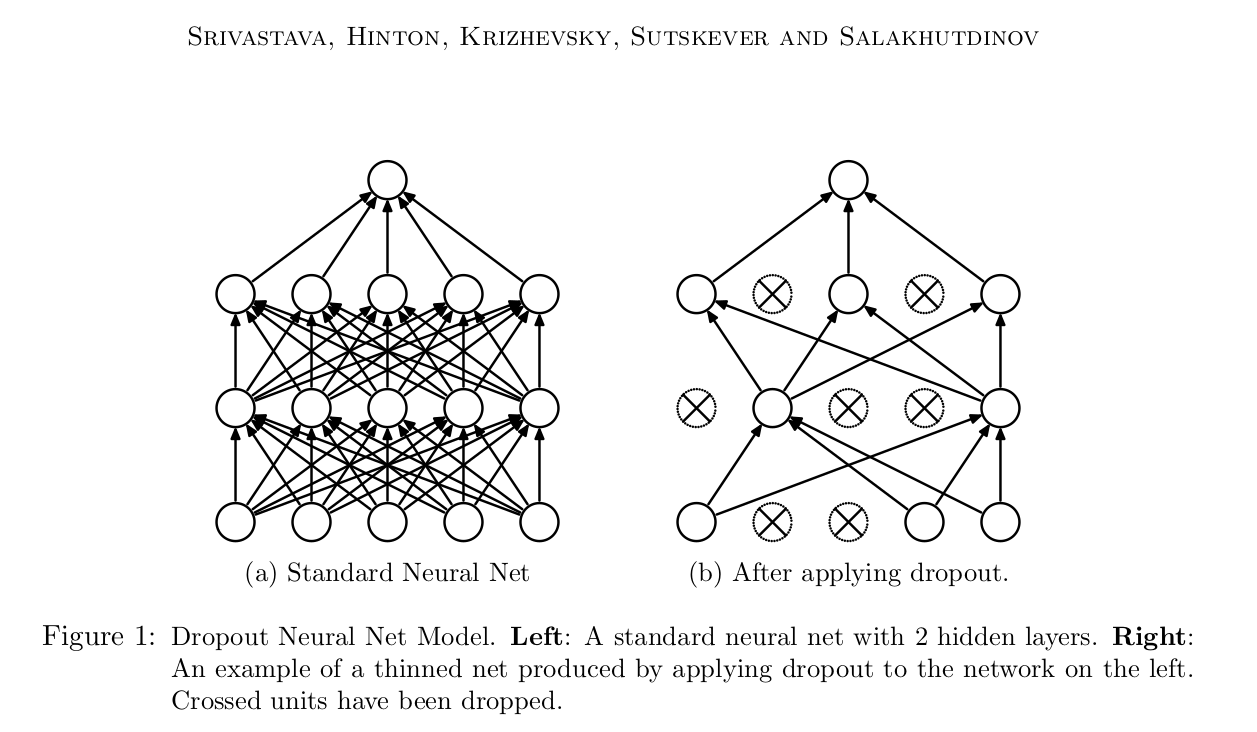


<p> <strong style="color:red;"> A cada vez que escolhemos uma época, escolhemos zerar neurônios diferentes, que são apagados aleatoriamente;
 </strong> <b>da estrutura da rede neural.</b> </p>


evita a rede neural generalizar e evitar que se adapte mais aos dados, 

escolher o parâmetro 0,1, zera 10% dos neurônios.

6 neurônios e colocamos 0,5 no parâmetro, zera a metade dos neurônios. 3 neurônios ativos e 3 neurônios parados.




### Estrutura da rede neural.

In [30]:
class classificador_torch_2(nn.Module):
  def __init__(self):
    super().__init__()

    # 30 -> 16 -> 16 -> 1
    # primeira camada linear
    self.dense0 = nn.Linear(30, 16)
    # inicialização dos pesos
    torch.nn.init.uniform_(self.dense0.weight)
    # dados de ativação
    self.activation0 = nn.ReLU()
    # unica alteração é feita aqui, utilizando o dropout
    # passaremos quantos porcentos dos neurônios queremos zerar, no caso 10% ou 0,1
    # vamos zerar os 10% dos 16 neurônios da primeira camada oculta.
    self.dropout0 = nn.Dropout(0.1)
    self.dense1 = nn.Linear(16, 16)
    torch.nn.init.uniform_(self.dense1.weight)
    self.activation1 = nn.ReLU()
    # agora vamos zerar os 10% dos 16 neurônios da segunda camada oculta.
    self.dropout1 = nn.Dropout(0.1)
    self.dense2 = nn.Linear(16, 1)
    torch.nn.init.uniform_(self.dense2.weight)
    # self.output = nn.Sigmoid() ** ATUALIZAÇÃO **
    
  # processo forward
  def forward(self, X):
    X = self.dense0(X)
    X = self.activation0(X)
    X = self.dropout0(X) # dropout 1
    X = self.dense1(X)
    X = self.activation1(X)
    X = self.dropout1(X) # dropout 2
    X = self.dense2(X)
    # X = self.output(X) ** ATUALIZAÇÃO **
    return X

In [31]:
classificador_sklearn_2 = NeuralNetBinaryClassifier(module=classificador_torch_2,
                                                  criterion=torch.nn.BCEWithLogitsLoss, # ** ATUALIZAÇÃO **
                                                  optimizer=torch.optim.Adam,
                                                  lr=0.001,
                                                  optimizer__weight_decay=0.0001,
                                                  max_epochs=100,
                                                  batch_size=10,
                                                  train_split=False)

In [32]:
# faremos a validação cruzada 
resultados_2 = cross_val_score(classificador_sklearn_2, previsores, classe, cv = 10, scoring = 'accuracy')

  epoch    train_loss     dur
-------  ------------  ------
      1    77497.2447  0.0821
      2    61948.2115  0.0336
      3    47429.6660  0.0389
      4    36760.8127  0.0742
      5    28266.0656  0.0762
      6    21042.6118  0.0783
      7    15048.9168  0.1006
      8    10654.0097  0.0756
      9     6646.8485  0.0741
     10     3504.9151  0.0745
     11     1777.1796  0.0741
     12     1574.6817  0.0743
     13     1201.0699  0.0743
     14      946.0826  0.0736
     15     1567.6352  0.0736
     16     1203.4452  0.0746
     17     1190.7607  0.0736
     18      988.6754  0.0745
     19     1033.2888  0.0733
     20     1124.4044  0.0752
     21     1114.8576  0.0902
     22      805.8267  0.0777
     23     1105.2342  0.0753
     24      982.1294  0.0747
     25      966.2609  0.0750
     26      806.7809  0.0769
     27      659.8865  0.0743
     28      755.4690  0.0797
     29      717.8291  0.0855
     30      639.7495  0.0446
     31      750.1383  0.0801
     32   

In [33]:
media = resultados_2.mean()
desvio = resultados_2.std()
media, desvio

(0.8013784461152882, 0.058303006634818216)

In [34]:
resultados_2

array([0.75438596, 0.78947368, 0.8245614 , 0.78947368, 0.85964912,
       0.66666667, 0.87719298, 0.85964912, 0.80701754, 0.78571429])

In [35]:
print('resultado final da precisão do acerto')
print(f'média acurácia das 10 validações cruzadas: {media*100:.2f} %')

print(f'Devio padrão da acurácia das 10 validações cruzadas: {desvio*100:.2f} %;')
print('Para verificar se os valores ficam dispersos.')
#Verificar a variação
print(f'Variação da acurácia dos valores: Máx.: {resultados_2.max()*100:.2f} % e Min: {resultados_2.min()*100:.2f} %, é de {(resultados_2.max()-resultados_2.min())*100:.2f} %.')


resultado final da precisão do acerto
média acurácia das 10 validações cruzadas: 80.14 %
Devio padrão da acurácia das 10 validações cruzadas: 5.83 %;
Para verificar se os valores ficam dispersos.
Variação da acurácia dos valores: Máx.: 87.72 % e Min: 66.67 %, é de 21.05 %.


In [37]:
# a ideia era melhor a acurácia
# quando desligavamos 20% dos neurônios os valores da acurácia ficaram menores.